<a href="https://colab.research.google.com/github/jirvingphd/ai-aoe-workshop-backup/blob/main/notebooks_fixed_vers/(AICOE_Workshop_03)_Vector_Databases_%26_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 3: Vector Embeddings & Databases

## Introduction

In this workshop, we will learn in-depth about different vector embedding and database storage techniques, which are essential tools for creating powerful Retrieval-Augmented Generation (RAG) applications.
RAGs combine the power of retrieval and generation, allowing AI models to access vast amounts of unstructured data and integrate external knowledge for more accurate, contextually relevant responses. By efficiently storing and retrieving information, RAGs enhance the performance of AI systems, enabling them to provide deeper insights and more precise outputs. Throughout this session, we will explore essential techniques such as data ingestion, document loaders, and chunking, providing a solid foundation for creating intelligent, scalable, and dynamic AI solutions.

## Data Ingestion

Data ingestion is the process of collecting and importing data from various sources into a system or storage solution for processing and analysis. In the context of AI applications, it involves gathering raw data, transforming it into usable formats, and storing it in a way that AI models can access and utilize effectively.

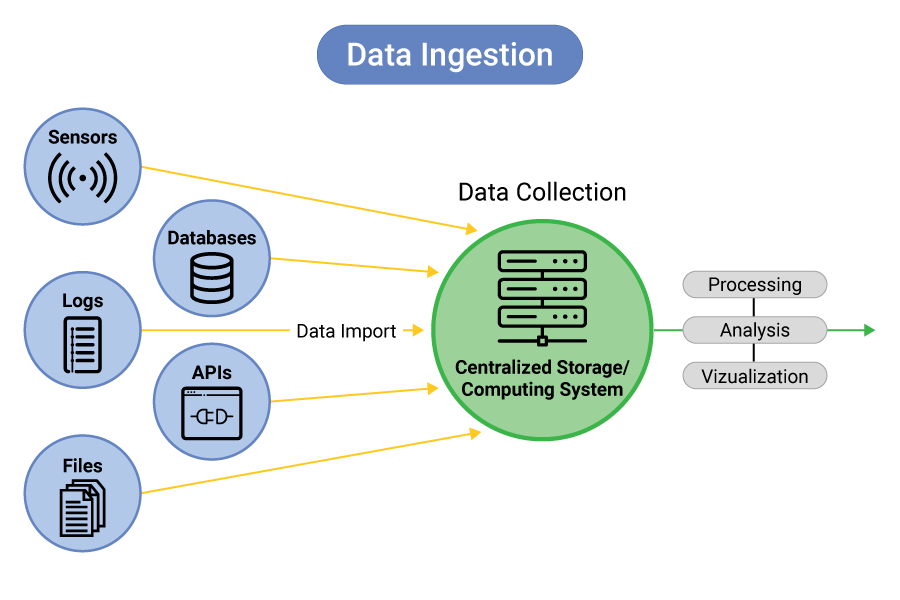

**Importance of Data Ingestion for AI Applications:**

1.   **Foundation for AI Workflows:** Provides the necessary data pipeline to feed AI models with structured and unstructured data for analysis.

2.   **Real-Time Processing:** Enables the handling of time-sensitive data, ensuring AI systems can respond to events as they occur.

3.   **Diversity of Data Sources:** Collects data from various formats and locations, ensuring comprehensive and robust datasets.

4.   **Improved Model Accuracy:** Supplies high-quality and diverse data, enhancing the precision and performance of AI models.

5.   **Automation:** Streamlines the process of data collection and preparation, reducing manual effort and improving efficiency.


**Data Ingestion techniques for AI applications:**

1.   **Batch Processing**: Batch processing is a technique where data is collected, stored, and processed in large volumes over a specified period. Data is ingested and processed in chunks, rather than as individual records or events.

2.   **Real-Time processing**: Real-time processing involves ingesting and processing data as it is generated, with minimal latency. This technique is designed for time-sensitive applications where immediate action or insights are required.

3.   **Lambda Architecture**: Lambda Architecture is a hybrid data ingestion approach that combines batch processing and real-time processing. It provides a unified solution for applications requiring both historical and real-time data analysis.

# Document Loaders

The primary purpose of document loaders is to seamlessly integrate data from diverse sources into a standardized document object. This document object comprises the content and its associated metadata, ensuring uniformity and consistency across varied datasets. By providing a structured and consistent interface, document loaders enable developers to streamline data handling processes and focus on building innovative and intelligent applications. It returns a list of **Document** objects

Ways to load data sources using a Document Loader:

1.   Custom Document Loader

2.   CSV

3.   File Directory

4.   HTML

5.   JSON

6.   Markdown

7.   Microsoft Office

8.   PDF

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


### Types of Document Loaders

LangChain has a collection of over 80 different types of document loaders, catering to a wide range of data sources and formats.

Most commonly used document loaders:



*   Text Loader
*   PyPDF Loader
*   WebBaseLoader



In [ ]:
#Install relevant libraries
# 08/08/25 - exact versions added
!pip install openai==1.98.0
!pip install langchain-openai==0.3.28
!pip install langchain==0.3.27
!pip install langchain-community==0.3.27

!pip install pypdf==5.9.0
!pip install langchain-text-splitters==0.3.9
!pip install bs4==0.0.2
!pip install requests==2.32.3
!pip install chromadb==1.0.16
!pip install sentence-transformers==4.1.0
!pip install langchain-huggingface==0.3.1
!pip install langchain-chroma==0.2.5

In [ ]:
# Import all the relevant libraries

from langchain_community.document_loaders import TextLoader, PyPDFLoader, WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter, HTMLHeaderTextSplitter, RecursiveJsonSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from getpass import getpass
import bs4
import json
import requests
import os
import warnings


warnings.filterwarnings("ignore")

In [ ]:
# #Define an OpenAI API Key
OPENAI_API_KEY = getpass('Enter the OpenAI API key value: ')
print("Successfully assigned an OpenAI API Key!")

# ## UPDATE FROM WORKSHOP 4
# from google.colab import userdata
# import os
# ## API Key from Secrets sidebar
# OPENAI_API_KEY =  userdata.get('OPENAI_API_KEY')

os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

**Example 1**: LangChain Text Loader

Langchain Text Loader is designed to handle **unstructured** data such as text files. The TextLoader class in LangChain is designed to facilitate the loading of **text files** into **Document objects**, which are fundamental units within the LangChain framework. Each Document comprises textual content and associated metadata, enabling consistent processing across various applications.

**Key Features of TextLoader:**

1.   **Flexible Text File Loading**: The TextLoader can efficiently load text files of varying sizes and formats, ensuring compatibility with diverse datasets.

2.   **Document Management**: TextLoader converts raw text into Document objects, which include both content and metadata. This structured format makes it easier to organize, process, and integrate data into AI pipelines.

3.   **Lazy and Asynchronous Loading**: TextLoader supports lazy loading, which loads data only when needed, and asynchronous loading, which handles data operations concurrently.

In [ ]:
# Define a TextLoader object with the AI_speech as input
loader=TextLoader('AI_speech.txt')
print("Loader object: \n", loader)
print("\n")

# Load the contents within the txt file into a new variable "text_documents"
text_documents=loader.load()

# text_documents contains a page_content variable and all the text from the file is present within this variable
print("Loaded Text Documents:")
text_documents

Loader object: 


Loaded Text Documents:


[Document(metadata={'source': 'AI_speech.txt'}, page_content='Artificial Intelligence (AI) is transforming many industries by automating tasks that were once done by humans. From manufacturing to healthcare, AI is enhancing efficiency, reducing costs, and enabling companies to provide better services. The impact of AI on automation can be seen in several key areas, including productivity, job displacement, and the creation of new opportunities.\n\nOne of the most significant impacts of AI on automation is increased productivity. Machines powered by AI can perform tasks faster and more accurately than humans, which boosts overall efficiency. In industries like manufacturing, robots equipped with AI can work around the clock without breaks, leading to higher output and lower production costs. This allows businesses to produce more goods in less time, ultimately benefiting consumers with lower prices and faster delivery.\n\nHowever, while AI-driven automation brings productivity benefits,

**Example 2**: PyPDF Loader

The PyPDFLoader is a component within the LangChain framework designed to facilitate the extraction of text and metadata from PDF files. It leverages the pypdf library to process PDF documents, converting each page into a Document object that includes both the textual content and associated metadata, such as the source file path and page number.

**Key Features of PyPDFLoader**

1.   **PDF Processing**: Extracts text and metadata from PDF files using the pypdf library.

2.   **Document Creation**: Converts each PDF page into a structured Document object with metadata like source and page number.

3.   **Lazy and Asynchronous Loading**: Improves performance by loading data incrementally (lazy) or concurrently (asynchronously) when needed.

In [ ]:
# Define a PyPDFLoader object with the "Attention is All You Need" research paper as input
loader=PyPDFLoader('attention.pdf')

# Loads the content of the attention.pdf as a list of document objects, every page is converted into a document object.
docs=loader.load()
docs

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszk

In [ ]:
type(docs)

list

In [ ]:
type(docs[0])

langchain_core.documents.base.Document

**Example 3**: WebBaseLoader

The WebBaseLoader is a component within the LangChain framework designed to facilitate the extraction of textual content from web pages. It utilizes the requests library to fetch web pages and BeautifulSoup for parsing HTML content, converting the extracted text into Document objects that include both the content and associated metadata, such as the source URL. IMSDbLoader, AZLyricsLoader, and CollegeConfidentialLoader help in creating custom logic for loading from a webpage. The loaded content is stored as a document object.

**Key Features of WebBaseLoader**

1.   **Web Page Retrieval**: Fetches web pages using the requests library for efficient content extraction.

2.   **HTML Parsing**: Uses BeautifulSoup to parse HTML and extract relevant text and metadata.

3.   **Lazy and Asynchronous Loading**: Handles web content loading incrementally or concurrently for better performance.

In [ ]:
loader=WebBaseLoader(web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
                     bs_kwargs=dict(parse_only=bs4.SoupStrainer(
                         class_=("post-title","post-content","post-header")
                                ))
                     )

In [ ]:
loader.load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

## Document Chunking

Chunking refers to the process of breaking down large documents into smaller, manageable pieces, or chunks, for more effective retrieval and generation.

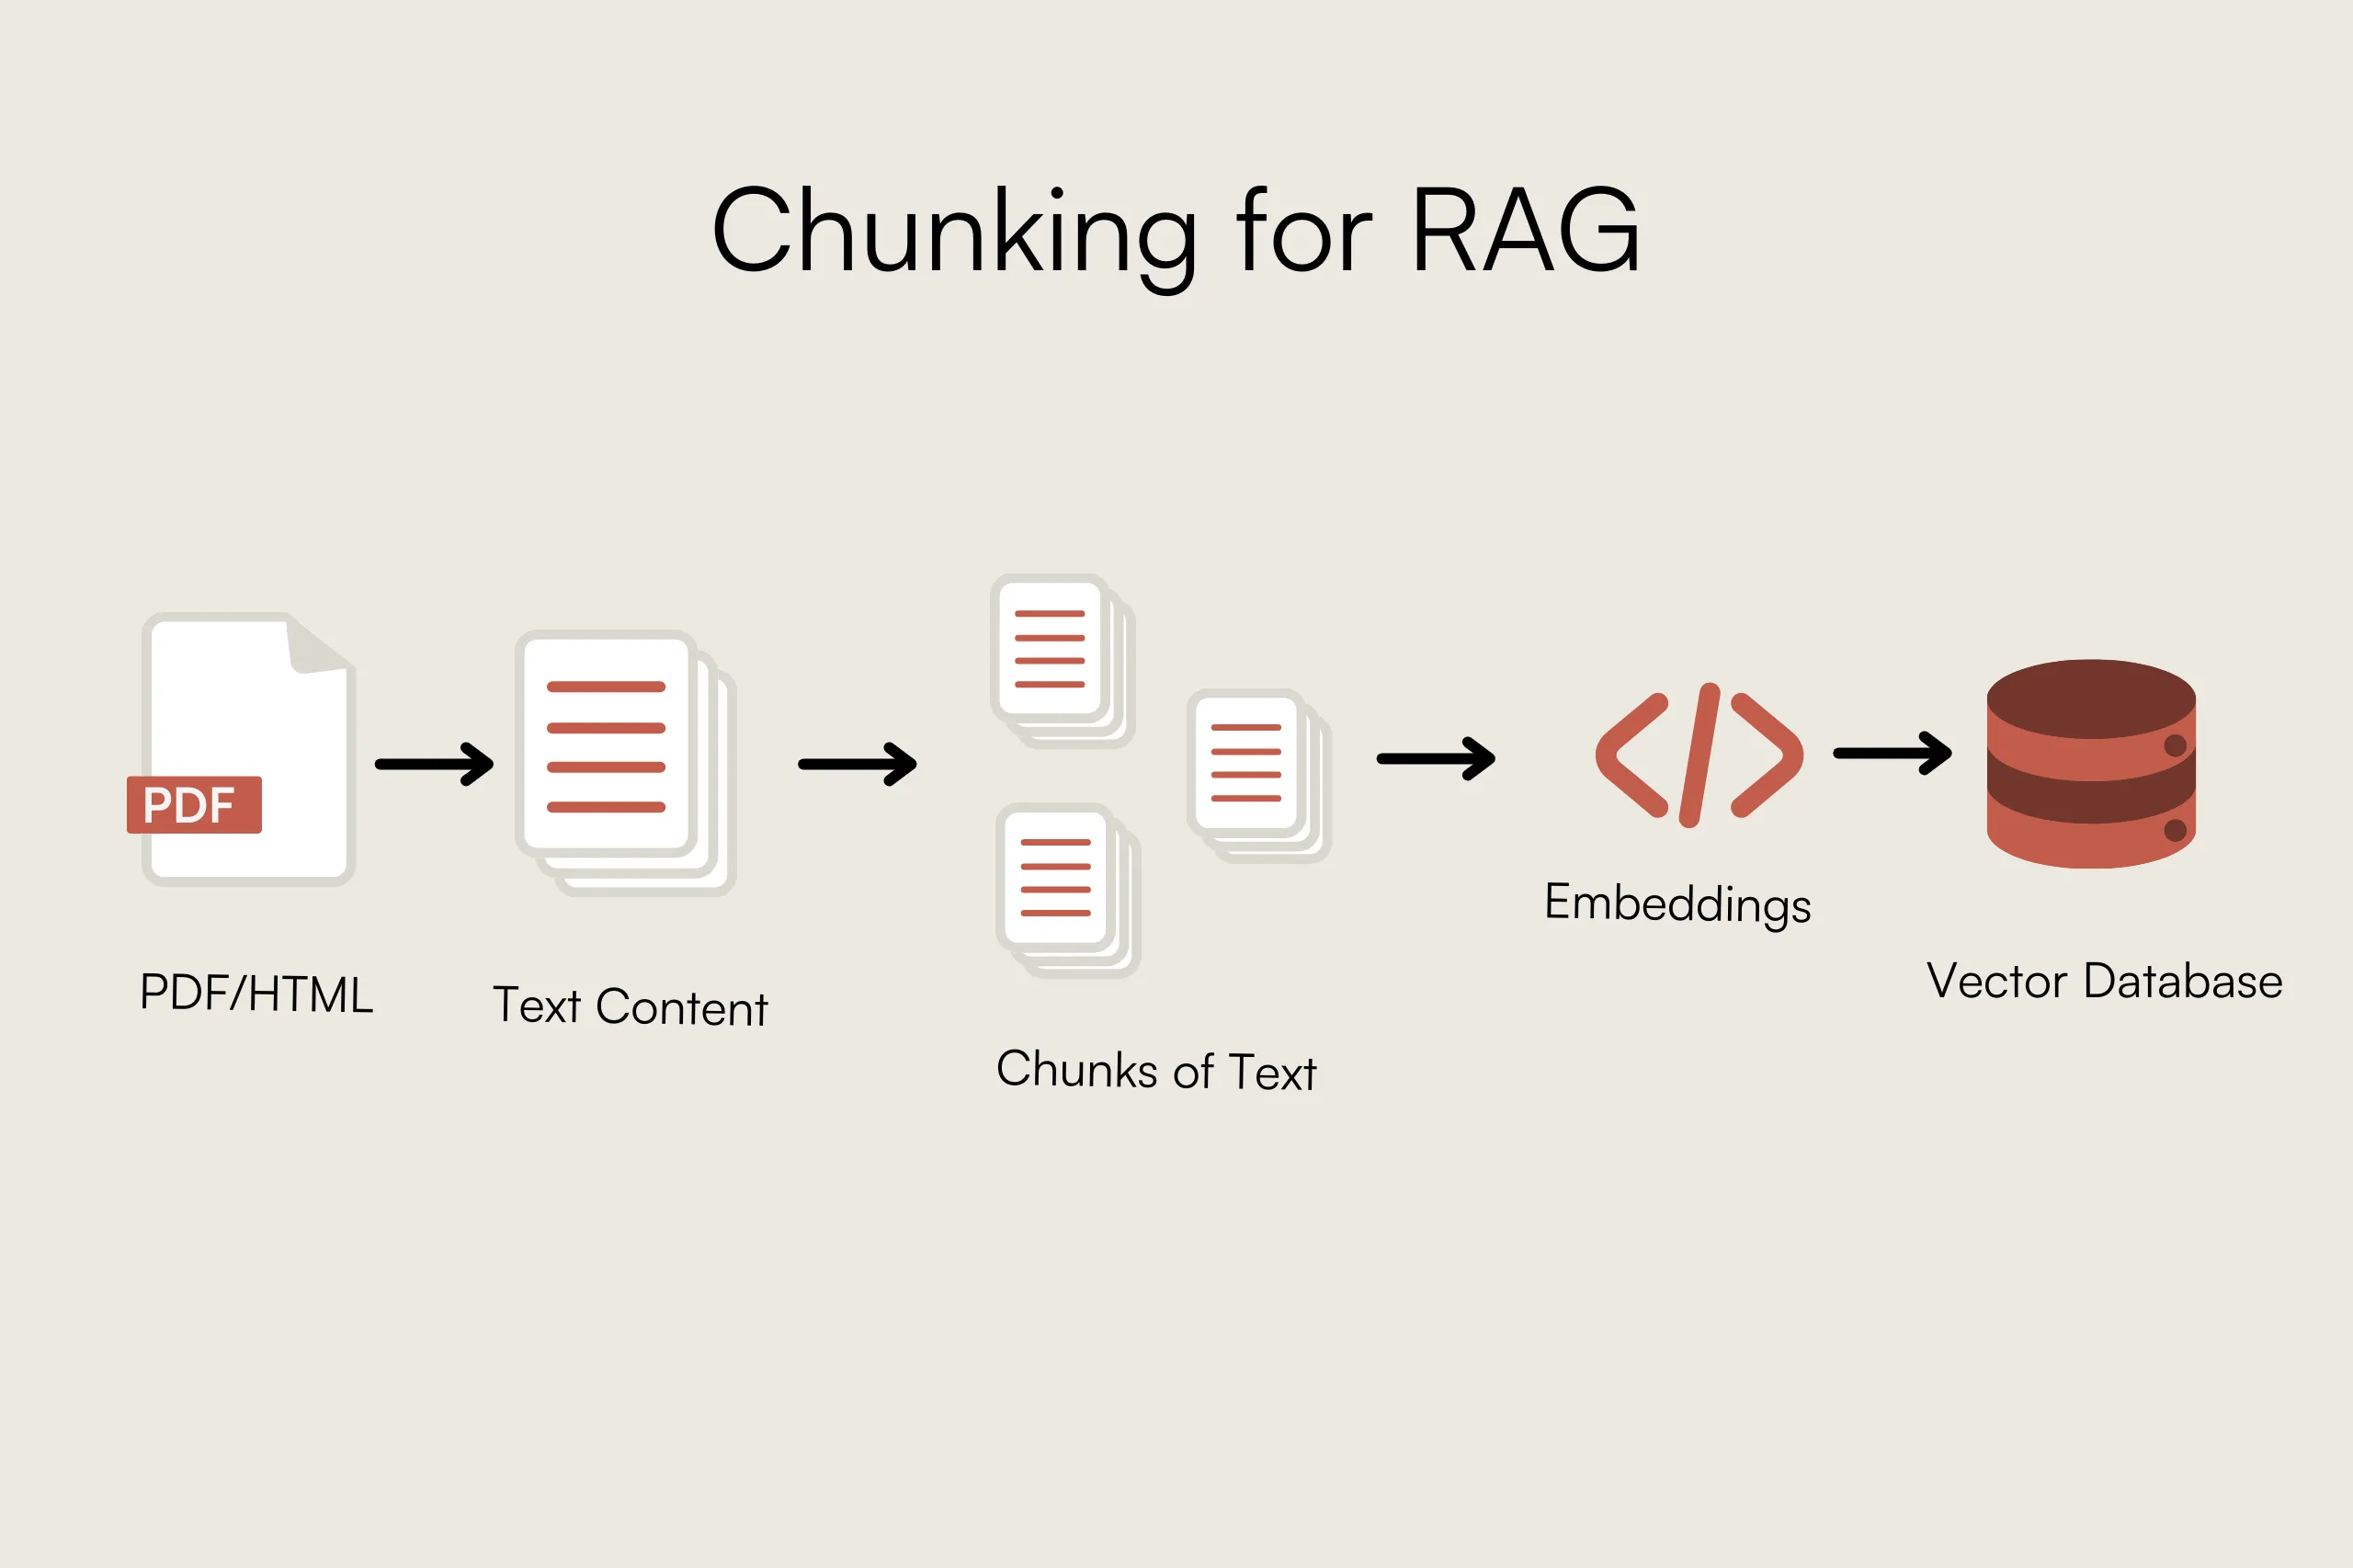

**Key Factors to Consider When Choosing a Chunking Method**

1.   **Size of Chunks:** Chunks can be based on tokens or sentences
2.   **Context Preservation:** Chunking is essential for maintaining the
semantic integrity of the document.
3.   **Handling Different Modalities:** RAG pipelines often deal with multi-modal documents, which may include text, images, and tables. Each modality requires different chunking strategies.

**Types of Document Chunking:**

There are approximately 15 diverse Document Chunking methods available, each tailored to address specific use cases and requirements in text processing and information retrieval. These methods enable users to efficiently segment text into manageable chunks while preserving context, enhancing accuracy, and optimizing performance for downstream applications like AI models and search engines.

Of these 15 types, the most commonly used chunking techniques are:

1.   Fixed-Size Chunking

2.   Sentence-Based Chunking
3.   Paragraph-Based Chunking
4.   Semantic-Based Chunking

| Chunking Method          | Description                                                   | When to Use                                                   | Advantages                                                | Disadvantages                                              | Trade-Offs                                                                 |
|--------------------------|---------------------------------------------------------------|----------------------------------------------------------------|-----------------------------------------------------------|------------------------------------------------------------|-----------------------------------------------------------------------------|
| Fixed-Size Chunking      | Splits text into chunks of predefined size<br>(e.g., word, token, or character count). | Simple processing of smaller, less complex documents.         | - Easy to implement<br>- Consistent chunk sizes<br>- Fast to compute | - May break sentences/paragraphs<br>- Loses context<br>- Not ideal for meaningful documents | Trades context preservation for simplicity and speed;<br>suitable for non-critical use cases. |
| Sentence-Based Chunking  | Splits text based on natural sentence boundaries.              | When maintaining coherent ideas is essential, avoiding mid-sentence splits. | - Preserves sentence-level meaning<br>- Better context preservation | - Uneven chunk sizes<br>- May exceed token limits if sentences are too long | Trades chunk size consistency for semantic coherence;<br>suitable for context-sensitive tasks. |
| Paragraph-Based Chunking | Divides text at paragraph boundaries,<br>treating each paragraph as a chunk. | For structured documents (e.g., reports, essays) where each paragraph represents a complete idea. | - Natural segmentation<br>- Preserves larger context       | - Uneven chunk sizes<br>- Long paragraphs may exceed token limits | Trades granularity for maintaining larger semantic units;<br>ideal for structured documents. |
| Semantic-Based Chunking  | Uses ML models to split text based on semantic meaning.        | When high context preservation is critical<br>(e.g., technical or complex documents). | - Contextually meaningful chunks<br>- Captures semantic relationships | - Requires advanced NLP models<br>- Computationally expensive<br>- Complex to implement | Trades simplicity for advanced context preservation;<br>suitable for high-value, complex tasks. |




```
# This is formatted as code
```

#### **Method 1**: Recursive Character Splitting Method (Fixed-Size Chunking)

The Recursive Character Text Splitter from LangChain is the recommended splitter for generic text. It attempts to split the text based on a predefined list of delimiters: **["\n\n", "\n", " ", ""]**, processing them in order until the resulting chunks are small enough. This approach ensures that larger semantically coherent units—such as paragraphs, sentences, and words—are preserved together as much as possible, since these are typically the most contextually related segments of the text.

**Example 1**: Using RecursiveCharacterTextSplitter on a single document containing multiple paragraphs

In [ ]:
# Recursively splitting text by characters

#Read in the input text as a plain string
with open("AI_speech.txt", "r") as f:
  speech = f.read()

print("Extracted Text: ")
print(speech)
print("==================================================\n")

# Define a RecursiveCharacterTextSplitter object with the relevant input parameters
## Chunk Size: The size of each chunk of text post splitting the loaded document
## Chunk Overlap: The character limit to which an overlap between any two consecutive chunks is permissible
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)


#Perform text splitting on input loaded document by using the create_documents
## NOTE: create_documents() will take in a list of string as the input
AI_speech_chunks = text_splitter.create_documents([speech]) #Each chunk will be a document object

print("First Chunk: ")
print(AI_speech_chunks[0])
print("==================================================\n")
print("\n Second Chunk: ")
print(AI_speech_chunks[1])
print("==================================================\n")

Extracted Text: 
Artificial Intelligence (AI) is transforming many industries by automating tasks that were once done by humans. From manufacturing to healthcare, AI is enhancing efficiency, reducing costs, and enabling companies to provide better services. The impact of AI on automation can be seen in several key areas, including productivity, job displacement, and the creation of new opportunities.

One of the most significant impacts of AI on automation is increased productivity. Machines powered by AI can perform tasks faster and more accurately than humans, which boosts overall efficiency. In industries like manufacturing, robots equipped with AI can work around the clock without breaks, leading to higher output and lower production costs. This allows businesses to produce more goods in less time, ultimately benefiting consumers with lower prices and faster delivery.

However, while AI-driven automation brings productivity benefits, it also raises concerns about job displacement. 

**Example 2**: Using RecursiveCharacterTextSplitter on a document containing multiple pages (Fixed Size Chunking)

In [ ]:
# Define a PyPDFLoader object with the "Attention is All You Need" research paper as input
loader=PyPDFLoader('attention.pdf')

# Loads the content of the attention.pdf as a list of document objects, every page is converted into a document object.
docs=loader.load()

# Define a RecursiveCharacterTextSplitter object with the relevant input parameters
## Chunk Size: The size of each chunk of text post splitting the loaded document
## Chunk Overlap: The character limit to which an overlap between any two consecutive chunks is permissible
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

# split_documents() will take in a list of document page contents as input
final_documents = text_splitter.split_documents(docs) #Each chunk will be a document object

print("First Chunk:")
print(final_documents[0])
print("==================================================\n")
print("\nSecond Chunk:")
print(final_documents[1])

First Chunk:
page_content='Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.edu' metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}


Second Chunk:
page_content='University of Toronto
aida

#### **Method 2**: Character Splitting Method(Fixed-Size Chunking (Character-Based))

The CharacterTextSplitter is a utility in LangChain designed to divide text into smaller, manageable chunks based on character count. This method is particularly useful when processing large documents that need to be broken down for tasks such as natural language processing or machine learning applications. CharacterTextSplitter splits based on a given character sequence, which defaults to "\n\n"

**Key Parameters:**

1.   **Chunk Size**: Specifies the maximum number of characters per chunk.

2.   **Chunk Overlap**: Determines the number of characters that overlap between consecutive chunks, ensuring context is maintained across chunks.


In [ ]:
#Read in the input text as a plain string
with open("AI_speech.txt", "r") as f:
  speech = f.read()

print("Extracted Text: ")
print(speech)
print("==================================================\n")

# Define a CharacterTextSplitter object with the required input parameters.
text_Splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=20)

speech_doc_chunks = text_Splitter.create_documents([speech])

print("First Chunk:")
print(speech_doc_chunks[0])
print("==================================================\n")
print("\nSecond Chunk:")
print(speech_doc_chunks[1])

Extracted Text: 
Artificial Intelligence (AI) is transforming many industries by automating tasks that were once done by humans. From manufacturing to healthcare, AI is enhancing efficiency, reducing costs, and enabling companies to provide better services. The impact of AI on automation can be seen in several key areas, including productivity, job displacement, and the creation of new opportunities.

One of the most significant impacts of AI on automation is increased productivity. Machines powered by AI can perform tasks faster and more accurately than humans, which boosts overall efficiency. In industries like manufacturing, robots equipped with AI can work around the clock without breaks, leading to higher output and lower production costs. This allows businesses to produce more goods in less time, ultimately benefiting consumers with lower prices and faster delivery.

However, while AI-driven automation brings productivity benefits, it also raises concerns about job displacement. 

In [ ]:
# Define a TextLoader object with the AI_speech as input
loader=TextLoader('AI_speech.txt')
docs = loader.load()

# Define a CharacterTextSplitter object with the required input parameters.
## CharacterTextSplitter prioritizes splitting on the separator over the chunk_size value
text_Splitter = CharacterTextSplitter(separator="\n\n",chunk_size=100, chunk_overlap=20)

# Use split_documents() method to take in a list of document objects
speech_doc_chunks = text_Splitter.split_documents(docs)

print("First Chunk:")
print(speech_doc_chunks[0])
print("==================================================\n")
print("\nSecond Chunk:")
print(speech_doc_chunks[1])

First Chunk:
page_content='Artificial Intelligence (AI) is transforming many industries by automating tasks that were once done by humans. From manufacturing to healthcare, AI is enhancing efficiency, reducing costs, and enabling companies to provide better services. The impact of AI on automation can be seen in several key areas, including productivity, job displacement, and the creation of new opportunities.' metadata={'source': 'AI_speech.txt'}


Second Chunk:
page_content='One of the most significant impacts of AI on automation is increased productivity. Machines powered by AI can perform tasks faster and more accurately than humans, which boosts overall efficiency. In industries like manufacturing, robots equipped with AI can work around the clock without breaks, leading to higher output and lower production costs. This allows businesses to produce more goods in less time, ultimately benefiting consumers with lower prices and faster delivery.' metadata={'source': 'AI_speech.txt'}


#### **Method 3**: HTML Header Text Splitter

HTMLHeaderTextSplitter is a **structure-aware** chunker that splits text at the HTML element level and adds metadata for each header **relevant** to any given chunk. It can return chunks element-by-element or combine elements with the same metadata, with the objects of:
</br>
1.   Keeping related text grouped semantically </br>
2.   Preserving context-rich information encoded in document structures. </br>

In a more complex use case, it can be used with other text splitters as part of a chunking pipeline

It is analogous to the **MarkdownHeaderTextSplitter** for markdown files.

In [ ]:
# Define a html string
html_string = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Effect of AI on the Climate</title>
</head>
<body>
    <header>
        <h1>The Effect of Artificial Intelligence on the Climate</h1>
        <p>Artificial Intelligence (AI) is playing an increasingly important role in tackling climate change. By using AI to analyze vast amounts of environmental data and optimize processes, we can develop more sustainable solutions and reduce the negative impact of human activity on the planet.</p>
    </header>

    <section>
        <h2>Positive Impacts of AI on the Environment</h2>
        <p>AI can help address climate change in numerous ways. One of the most significant applications is in energy efficiency. AI-powered systems can optimize the use of energy in buildings, manufacturing processes, and transportation, reducing waste and emissions. For example, AI can predict energy demand, optimize heating and cooling systems, and improve the efficiency of renewable energy sources like solar and wind.</p>
    </section>

    <article>
        <h3>AI in Climate Monitoring and Data Analysis</h3>
        <p>AI can also assist in monitoring climate patterns and providing more accurate forecasts. By analyzing vast datasets from satellites, sensors, and climate models, AI can identify patterns and trends in temperature, air quality, and carbon emissions. This information can be used to better understand climate change and inform policy decisions aimed at mitigating its effects.</p>
    </article>

    <section>
        <h2>Challenges and Risks of AI for the Environment</h2>
        <p>While AI has great potential for environmental benefits, there are also concerns about its impact on the climate. The training and operation of AI models require significant computational resources, which in turn consume large amounts of energy. The environmental footprint of AI could offset some of its positive contributions, especially if data centers and AI operations are powered by non-renewable energy sources.</p>
    </section>

    <article>
        <h3>Balancing AI's Energy Use with Environmental Goals</h3>
        <p>To maximize the benefits of AI while minimizing its negative effects, it's crucial that AI technologies are powered by renewable energy and designed to be as energy-efficient as possible. Researchers and companies are already working on ways to make AI systems more sustainable, such as optimizing algorithms to reduce energy consumption and building AI data centers with green energy solutions.</p>
    </article>

    <footer>
        <p>The effect of AI on the climate presents both opportunities and challenges. By leveraging AI responsibly and ensuring its integration with sustainable practices, we can unlock its full potential in the fight against climate change.</p>
    </footer>
</body>
</html>
"""

#Define the headers to split on
headers_to_split_on = [
    ("h1", "Header 1"),
    ("h2", "Header 2"),
    ("h3", "Header 3"),
]

# Define a HTMLHeaderTextSplitter object with input as the "headers_to_split_on" parameter
html_splitter = HTMLHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
html_header_splits = html_splitter.split_text(html_string)
html_header_splits




[Document(metadata={'Header 1': 'The Effect of Artificial Intelligence on the Climate'}, page_content='The Effect of Artificial Intelligence on the Climate'),
 Document(metadata={'Header 1': 'The Effect of Artificial Intelligence on the Climate'}, page_content='Artificial Intelligence (AI) is playing an increasingly important role in tackling climate change. By using AI to analyze vast amounts of environmental data and optimize processes, we can develop more sustainable solutions and reduce the negative impact of human activity on the planet.'),
 Document(metadata={'Header 1': 'The Effect of Artificial Intelligence on the Climate', 'Header 2': 'Positive Impacts of AI on the Environment'}, page_content='Positive Impacts of AI on the Environment'),
 Document(metadata={'Header 1': 'The Effect of Artificial Intelligence on the Climate', 'Header 2': 'Positive Impacts of AI on the Environment'}, page_content='AI can help address climate change in numerous ways. One of the most significant ap

In [ ]:
#Define the url to extract text from
url = "https://plato.stanford.edu/entries/artificial-intelligence/"

#Define the headers to split on
headers_to_split_on = [
    ("h1", "Header 1"),
    ("h2", "Header 2"),
    ("h3", "Header 3"),
    ("h4", "Header 4"),
]

# Define a HTMLHeaderTextSplitter object with input as the "headers_to_split_on" parameter
html_splitter = HTMLHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
html_header_splits = html_splitter.split_text_from_url(url)

print("First Chunk:")
print(html_header_splits[0])
print("==================================================\n")
print("\nSecond Chunk:")
print(html_header_splits[1])

First Chunk:
page_content='End container NOTE: Script required for drop-down button to work (mirrors).  
End header wrapper End content End footer  
End header  
End navigation End search  
Stanford Encyclopedia of Philosophy  
Menu  
Browse  
Table of Contents  
What's New  
Random Entry  
Chronological  
Archives  
About  
Editorial Information  
About the SEP  
Editorial Board  
How to Cite the SEP  
Special Characters  
Advanced Tools  
Contact  
Support SEP  
Support the SEP  
PDFs for SEP Friends  
Make a Donation  
SEPIA for Libraries  
Begin article sidebar End article sidebar NOTE: Article content must have two wrapper divs: id="article" and id="article-content" End article NOTE: article banner is outside of the id="article" div. End article-banner  
Entry Navigation  
Entry Contents  
Bibliography  
Academic Tools  
Friends PDF Preview  
Author and Citation Info  
Back to Top  
End article-content  
BEGIN ARTICLE HTML #aueditable DO NOT MODIFY THIS LINE AND BELOW END ARTICLE 

#### **Method 4**: Recursive JSON Splitter (Hierarchical Chunking)

This json splitter traverses json data depth first and builds smaller json chunks. It attempts to keep nested json objects whole but will split them if needed to keep chunks between a min_chunk_size and the max_chunk_size. If the value is not a nested json, but rather a very large string the string will not be split.

There is an optional pre-processing step to split lists, by first converting them to json (dict) and then splitting them as such.

1.   How the text is split: json value.
2.   How the chunk size is measured: by number of characters.

In [ ]:
# Define a JSON string
sweet_recipes = {
		"id": "0001",
		"type": "donut",
		"name": "Cake",
		"ppu": 0.55,
		"batters":
			{
				"batter":
					[
						{ "id": "1001", "type": "Regular" },
						{ "id": "1002", "type": "Chocolate" },
						{ "id": "1003", "type": "Blueberry" },
						{ "id": "1004", "type": "Devil's Food" }
					]
			},
		"topping":
			[
				{ "id": "5001", "type": "None" },
				{ "id": "5002", "type": "Glazed" },
				{ "id": "5005", "type": "Sugar" },
				{ "id": "5007", "type": "Powdered Sugar" },
				{ "id": "5006", "type": "Chocolate with Sprinkles" },
				{ "id": "5003", "type": "Chocolate" },
				{ "id": "5004", "type": "Maple" }
			]
	}

#Define a RecursiveJsonSplitter object with maximum chunk size specified to 300 characters
json_splitter = RecursiveJsonSplitter(max_chunk_size = 300)
json_chunks = json_splitter.split_json(sweet_recipes) # We can also use the split_text function to extract json chunks

for chunk in json_chunks:
  print(chunk)
  print("\n")

{'id': '0001', 'type': 'donut', 'name': 'Cake', 'ppu': 0.55, 'batters': {'batter': [{'id': '1001', 'type': 'Regular'}, {'id': '1002', 'type': 'Chocolate'}, {'id': '1003', 'type': 'Blueberry'}, {'id': '1004', 'type': "Devil's Food"}]}}


{'topping': [{'id': '5001', 'type': 'None'}, {'id': '5002', 'type': 'Glazed'}, {'id': '5005', 'type': 'Sugar'}, {'id': '5007', 'type': 'Powdered Sugar'}, {'id': '5006', 'type': 'Chocolate with Sprinkles'}, {'id': '5003', 'type': 'Chocolate'}, {'id': '5004', 'type': 'Maple'}]}




In [ ]:
# Uing json splitter to create documents
docs = json_splitter.create_documents([sweet_recipes])

for doc_chunk in docs:
  print(doc_chunk)
  print("\n")

page_content='{"id": "0001", "type": "donut", "name": "Cake", "ppu": 0.55, "batters": {"batter": [{"id": "1001", "type": "Regular"}, {"id": "1002", "type": "Chocolate"}, {"id": "1003", "type": "Blueberry"}, {"id": "1004", "type": "Devil's Food"}]}}'


page_content='{"topping": [{"id": "5001", "type": "None"}, {"id": "5002", "type": "Glazed"}, {"id": "5005", "type": "Sugar"}, {"id": "5007", "type": "Powdered Sugar"}, {"id": "5006", "type": "Chocolate with Sprinkles"}, {"id": "5003", "type": "Chocolate"}, {"id": "5004", "type": "Maple"}]}'




## Embeddings & Vector Databases

### Vector Embeddings

Word embeddings are ways to **represent words as numbers** that capture their meaning and how they semantically relate to other words. These numbers are created by training a machine learning model on a lot of text. The model learns to give each word a unique set of numbers, called a vector.

For example, the numbers representing the word "cat" are learned during training. Since words like "cats" and "dogs" often appear together, the model will place these words closer in the vector space.

We call them "embeddings" because the model puts each word into a space of numbers. This method can also be used for phrases or sentences, not just individual words, to capture their meaning in the same way.

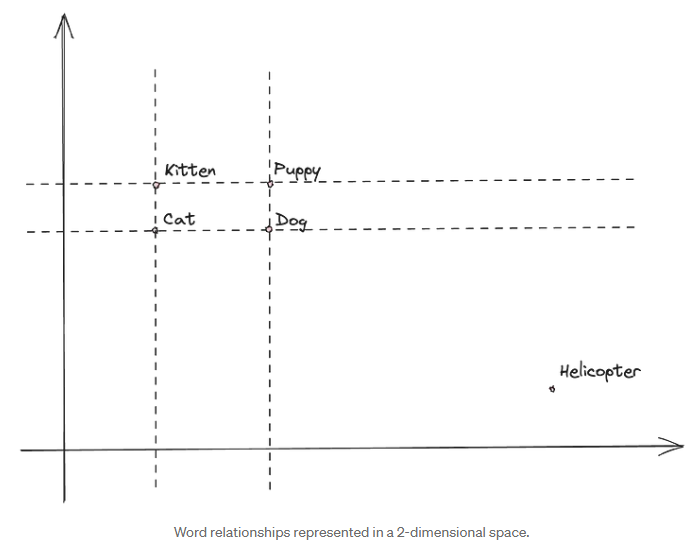

Vector embeddings come in different types, each designed to represent different kinds of data. Here are some common types: </br>

- **Word embeddings**: These are vectors that represent individual words. They are often used to understand relationships between words, such as in sentiment analysis, language translation, and finding similar words. </br>

- **Sentence embeddings**: These are vectors that represent entire sentences. They help in tasks like sentiment analysis, categorizing text, and searching for relevant information, as they capture the meaning and context of a whole sentence. </br>

- **Document embeddings**: These are vectors for entire documents, like articles or reports. They're used in tasks such as finding similar documents, grouping them, and recommending content, as they capture the overall meaning and content of a document. </br>

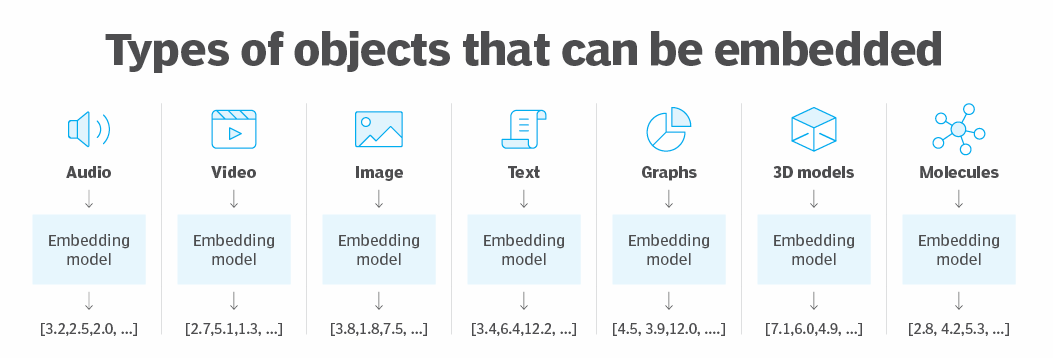

#### HunggingFace Embeddings

[Sentence Transformers](https://huggingface.co/sentence-transformers) on Hugging Face are models that can convert entire sentences into fixed-size vector embeddings. These embeddings capture the meaning and context of sentences, making it easier to compare or analyze them.  </br>

On Hugging Face, these models are easy to access and can be fine-tuned for specific tasks. By turning sentences into vectors, they allow you to efficiently search for similar sentences, group them, or even perform translation tasks.

Below is a step-by-step instruction guide on how you can use open-source pre-trained HuggingFace sentence transformer models for tasks such as text-to-vector embeddings: </br>
1) Install the necessary libraries (langchain_huggingface and sentence-transformers) using pip. </br>
2) Load a pre-trained Sentence Transformer model (e.g.: all-MiniLM-L6-v2 - a small, but powerful pre-trained model) using **HuggingFaceEmbeddings()**. </br>
3) Prepare your sentences and generate vector embeddings using the model's **embed_query()** method.</br></br>

In [ ]:
# # Set up a HuggingFace Access token as an environment variable
# HF_TOKEN = getpass('Enter the HF Token value: ')
# print("Successfully assigned a HF access token!")

## UPDATE FROM WORKSHOP 4
from google.colab import userdata
import os
## API Key from Secrets sidebar
HF_TOKEN =  userdata.get('HF_TOKEN')

## Alternative Way - Paste in Key with getpass
# from getpass import getpass
# #Define an OpenAI API Key
# os.environ['OPENAI_API_KEY'] = getpass('Enter the OpenAI API key value: ')
# print("Successfully assigned an OpenAI API Key!")


os.environ["HF_TOKEN"] = HF_TOKEN

In [ ]:
# Define the HuggingFace embeddings model
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

print("Embedding Model Loaded: ")
print(embeddings)
print("=========================================\n")

In [ ]:
# Create a test document
test_text = "This is a test document"

query_result = embeddings.embed_query(test_text)

print("Query Result: ")
print(query_result)
print("=========================================\n")


print("Length of Query Result: ")
print(len(query_result))
print("=========================================\n")

Query Result: 
[-0.048207882791757584, 0.11789613962173462, -0.03746982663869858, 0.056620460003614426, 0.015501760877668858, -0.03674929589033127, -0.05957154184579849, 0.05720915645360947, -0.02075633965432644, 0.057084690779447556, 0.07765136659145355, 0.01893668808043003, 0.0006362407584674656, -0.00040408625500276685, -0.06529415398836136, -0.028550080955028534, -0.011813518591225147, -0.04569052904844284, -0.007525649853050709, 0.08929040282964706, 0.05310368537902832, 0.06305599212646484, -0.0045524840243160725, 0.00036092655500397086, 0.008460144512355328, 0.030092932283878326, -0.06308871507644653, 0.03805891051888466, 0.08158416301012039, -0.05816446617245674, 0.032057613134384155, 0.06851986050605774, 0.07797116041183472, 0.034169308841228485, 0.06476922333240509, 0.004228671547025442, 0.07276923954486847, 0.002517923479899764, 0.03840570151805878, 0.03519797697663307, -0.017656544223427773, -0.11470241844654083, 0.009409707970917225, 0.03478091582655907, 0.02008695714175701

#### OpenAI Embeddings

OpenAI’s text embeddings measure the **relatedness** of text strings. it offers a set of models that output embeddings. The latest, text-embedding-3-large, performs best and is reasonably priced ($0.065 per 1M tokens) </br>

The embedding API is simpler than the completion APIs. It has 2 parameters: </br>

* **model** – The model we want to use for the embedding, in our case this will be text-embedding-3-large. </br>
* **input** – A string or array of tokens – the text for which we want the embedding. </br>

Since an embedding is a vector (list) of floating point numbers, the distance between two vectors measures their relatedness. Small distances suggest high relatedness and large distances suggest low relatedness.

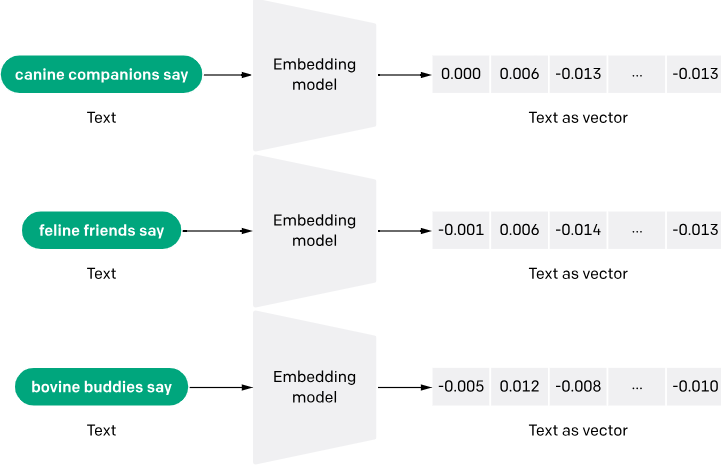

In [ ]:
# Set the OpenAI API Key

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

# Define a OpenAIEmbeddings object with the "text-embedding-3-large" model
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

print("Embeddings:")
print(embeddings)
print("=========================================\n")

test_text = "This is our third AI-focused workshop."

#Embed the text into a numerical vector
embedded_text = embeddings.embed_query(test_text)

print("Embedded Text:")
print(embedded_text)
print("=========================================\n")

print("First embedding value: ")
print(embedded_text[0])
print("=========================================\n")

print("Length of embedded text: ")
print(len(embedded_text))
print("=========================================")


Embeddings:
client=<openai.resources.embeddings.Embeddings object at 0x7b5b05aa8510> async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x7b5b04474cd0> model='text-embedding-3-large' dimensions=None deployment='text-embedding-ada-002' openai_api_version=None openai_api_base=None openai_api_type=None openai_proxy=None embedding_ctx_length=8191 openai_api_key=SecretStr('**********') openai_organization=None allowed_special=None disallowed_special=None chunk_size=1000 max_retries=2 request_timeout=None headers=None tiktoken_enabled=True tiktoken_model_name=None show_progress_bar=False model_kwargs={} skip_empty=False default_headers=None default_query=None retry_min_seconds=4 retry_max_seconds=20 http_client=None http_async_client=None check_embedding_ctx_length=True

Embedded Text:
[0.0049394527450203896, -0.011247669346630573, -0.022554850205779076, -0.02890770137310028, 0.052340347319841385, 0.008584531024098396, -0.0002659419260453433, 0.07724589854478836, 0.030916213

In [ ]:
#Embed the text into a numerical vector of a specified dimension
embeddings = OpenAIEmbeddings(model="text-embedding-3-large", dimensions = 1024)

#Embed the text into a numerical vector
embedded_text = embeddings.embed_query(test_text)
len(embedded_text)

1024

## Vector Databases

In a vector database, embeddings are used to organize and store text. When you want to find similar text to a specific input user query, the database compares the query's embedding with those of other texts by calculating the distance between them. This helps quickly identify the most similar pieces of text. </br>

For example, in a document search app, texts can be represented as vectors based on features like meaning, topic, and style. When you search for similar documents, the app compares the embeddings to find texts that match your preferences. </br>

Vector embeddings turn complex text into numerical representations, and vector databases use them to quickly search for and retrieve similar texts based on their location in the vector space. </br>

**Types of Vector Databases:**
1. Pure
2. Integrated
**Pure Vectore Database:** A pure vector database focuses on efficiently storing and managing vector embeddings with minimal metadata, separate from the source data.

**Integrated Vector Database:** An integrated vector database combines embeddings with the original data in a NoSQL or relational database, reducing replication costs, enabling multi-modal operations, and enhancing data consistency, scalability, and performance—ideal for AI-driven applications.

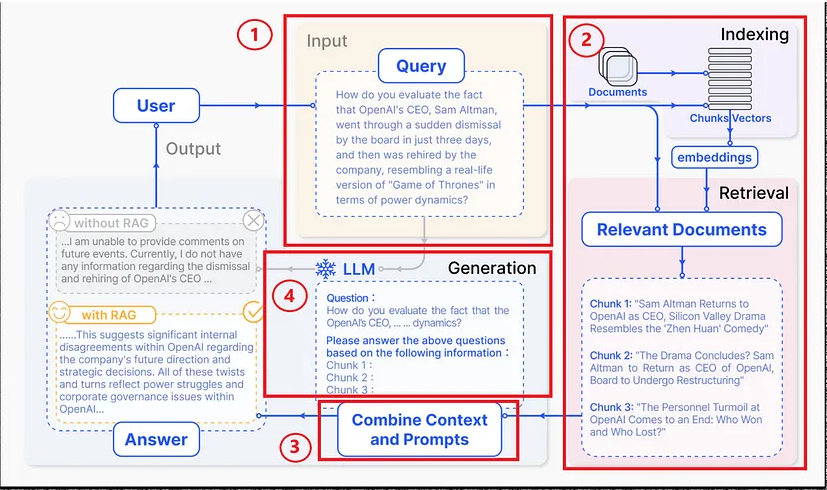

Vector databases are important because of their unique capabilities and wide range of applications:

- **Efficient Similarity Search**: Vector databases are great at finding similar items quickly, which is useful for recommendation systems, image/video retrieval, facial recognition, and searching for information.

- **Handling High-Dimensional Data**: Unlike traditional databases, vector databases manage high-dimensional data well, making them ideal for applications in fields like natural language processing, computer vision, and genomics.

- **Machine Learning and AI**: They are commonly used to store embeddings from machine learning models, which capture key features of data for tasks like clustering, classification, and anomaly detection.

- **Real-time Applications**: Many vector databases support fast, real-time queries, making them perfect for applications needing quick responses, such as e-commerce recommendations, fraud detection, and monitoring IoT devices.

- **Personalization and User Profiling**: Vector databases enable personalized experiences by allowing systems to understand and predict user preferences. This is crucial in platforms like streaming services, social media, and online marketplaces.

Common examples of well-known vector databases are PineCone, ChromaDB, Milvus, Weaviate, etc.

In [ ]:
#Step 1: Load the relevant text file
loader = TextLoader('AI_speech.txt')
docs = loader.load()

#Step 2: Split it into smaller text chunks
# Define a RecursiveCharacterTextSplitter object with the relevant input parameters
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

# split_documents() will take in a list of document page contents as input
final_documents = text_splitter.split_documents(docs) #Each chunk will be a document object

print("First three document chunks: ")
print(final_documents[:3])
print("===================================\n")

#Step 3: Convert each document into vector embeddings and save them on a vector database (Eg: ChromaDB)

#Embed the text into a numerical vector of a specified dimension
embeddings = OpenAIEmbeddings(model="text-embedding-3-large", dimensions = 1024)

# Define a vector store DB
db = Chroma.from_documents(final_documents, embeddings)

print("Chroma DB Location: ")
print(db)
print("===================================\n")

# Step 4: Perform retrieval of similarity results from vector DB based on a user query
query = "AI is transforming industries by automating tasks and creating demand for new, specialized jobs."
retrieved_results = db.similarity_search(query)

print("Top 1 Most Similar Retrieved Results:")
print(retrieved_results)
print("===================================\n")




First three document chunks: 
[Document(metadata={'source': 'AI_speech.txt'}, page_content='Artificial Intelligence (AI) is transforming many industries by automating tasks that were once done by humans. From manufacturing to healthcare, AI is enhancing efficiency, reducing costs, and enabling companies to provide better services. The impact of AI on automation can be seen in several key areas, including productivity, job displacement, and the creation of new opportunities.'), Document(metadata={'source': 'AI_speech.txt'}, page_content='One of the most significant impacts of AI on automation is increased productivity. Machines powered by AI can perform tasks faster and more accurately than humans, which boosts overall efficiency. In industries like manufacturing, robots equipped with AI can work around the clock without breaks, leading to higher output and lower production costs. This allows businesses to produce more goods in less time, ultimately benefiting consumers with lower price

You can save vector embeddings to disk using Chroma with Chroma.from_documents(), then load them back with Chroma() to perform similarity searches on queries. This allows you to easily store and retrieve embeddings for fast searches on relevant documents.

In [ ]:
#Saving embeddings to disk
vdb = Chroma.from_documents(documents=final_documents, embedding=embeddings, persist_directory="./chroma_db")

#Loading embeddings from disk
#Note: We need to use the same embedder for saving and loading the documents from the DB to help yield correct results
db2 = Chroma(persist_directory="./chroma_db", embedding_function=embeddings)

#Define the query to perform similarity search on the loaded vector db
query = "AI is transforming industries by automating tasks and creating demand for new, specialized jobs."

#Perform similarity search
docs = db2.similarity_search(query)

print(docs[0].page_content)


Despite these challenges, AI is also creating new job opportunities. As automation increases, there is a growing demand for skilled workers who can design, maintain, and manage AI systems. Jobs in fields like data science, AI programming, and robotics are on the rise. Moreover, AI can assist humans in their work by automating routine tasks, allowing employees to focus on more complex and creative aspects of their jobs. This shift in the nature of work could lead to more meaningful and rewarding


## Retrievers

A retriever is an **interface that returns documents given an unstructured query**. It is more general than a vector store. A retriever does not need to be able to store documents, only to return (or retrieve) them. Vector stores can be used as the backbone of a retriever

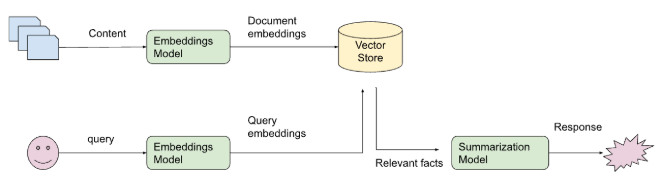

In [ ]:
#Setting up vector DB as a retriever
retriever = db2.as_retriever()

#Use retriever to extract most similar top 1 result on user query
retriever.invoke(query)[0]

Document(metadata={'source': 'AI_speech.txt'}, page_content='Despite these challenges, AI is also creating new job opportunities. As automation increases, there is a growing demand for skilled workers who can design, maintain, and manage AI systems. Jobs in fields like data science, AI programming, and robotics are on the rise. Moreover, AI can assist humans in their work by automating routine tasks, allowing employees to focus on more complex and creative aspects of their jobs. This shift in the nature of work could lead to more meaningful and rewarding')

## Reference Links

- https://medium.com/@vladris/embeddings-and-vector-databases-732f9927b377
- https://www.pinecone.io/learn/vector-database/
- https://platform.openai.com/docs/guides/embeddings
- https://dev.to/pavanbelagatti/wtf-is-a-vector-database-a-beginners-guide-16p
- https://www.analyticsvidhya.com/blog/2023/11/rag-langchain-and-vector-databases/?utm_source=chatgpt.com#h-how-do-vector-databases-store-and-retrieve-data